<a href="https://colab.research.google.com/github/sagarreverse-sudo/diabetes_xai_dissertation/blob/main/dissertation_xdiabetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dissertation diabetic

import

In [2]:

# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine learning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# General utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")
print("Google Colab environment is ready.")

Libraries imported successfully.
Google Colab environment is ready.


Paths and directory

In [3]:
from pathlib import Path

# Main dissertation workspace inside Google Colab
PROJECT_DIR = Path("/content/diabetes_xai_dissertation")

# Separate folders for raw data, cleaned data and results
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
CLEAN_DIR = DATA_DIR / "clean"
RESULTS_DIR = PROJECT_DIR / "results"

# Create the folders
for folder in [PROJECT_DIR, DATA_DIR, RAW_DIR, CLEAN_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dissertation workspace created successfully.")
print(f"Project folder: {PROJECT_DIR}")
print(f"Raw data folder: {RAW_DIR}")
print(f"Clean data folder: {CLEAN_DIR}")
print(f"Results folder: {RESULTS_DIR}")

Dissertation workspace created successfully.
Project folder: /content/diabetes_xai_dissertation
Raw data folder: /content/diabetes_xai_dissertation/data/raw
Clean data folder: /content/diabetes_xai_dissertation/data/clean
Results folder: /content/diabetes_xai_dissertation/results


In [5]:
from google.colab import files
import shutil

print("Select the NHS data files used in the dissertation.")
print("You can select multiple files at the same time.\n")

uploaded = files.upload()

for filename in uploaded.keys():
    source = Path("/content") / filename
    destination = RAW_DIR / filename

    if source.exists():
        shutil.move(str(source), str(destination))

print("\nFiles successfully uploaded:")
for file in RAW_DIR.iterdir():
    print(" -", file.name)

Select the NHS data files used in the dissertation.
You can select multiple files at the same time.



Saving National Diabetes Audit 2020-21 Data Release, England.xlsx to National Diabetes Audit 2020-21 Data Release, England.xlsx
Saving National Diabetes Audit 2021-22 Data Release, England v2.xlsx to National Diabetes Audit 2021-22 Data Release, England v2.xlsx
Saving National Diabetes Audit 2024-25 Data Release, England primary care.xlsx to National Diabetes Audit 2024-25 Data Release, England primary care.xlsx
Saving Open data - Chronic kidney disease.csv to Open data - Chronic kidney disease.csv
Saving Open data - Specification.xlsx to Open data - Specification.xlsx
Saving qof-2425-icb-ach-prev-pca.xlsx to qof-2425-icb-ach-prev-pca.xlsx

Files successfully uploaded:
 - National Diabetes Audit 2024-25 Data Release, England primary care.xlsx
 - qof-2425-icb-ach-prev-pca.xlsx
 - Open data - Specification.xlsx
 - National Diabetes Audit 2021-22 Data Release, England v2.xlsx
 - National Diabetes Audit 2020-21 Data Release, England.xlsx
 - National Diabetes Audit 2019-20 Data Release, Int

Check upload

In [6]:
print("Checking uploaded dissertation data files...\n")

raw_files = sorted(RAW_DIR.iterdir())

if len(raw_files) == 0:
    print("No files found in the raw data folder.")
else:
    print(f"Total files found: {len(raw_files)}\n")

    for i, file in enumerate(raw_files, start=1):
        size_mb = file.stat().st_size / (1024 * 1024)

        print(f"{i}. {file.name}")
        print(f"   File type: {file.suffix}")
        print(f"   Size: {size_mb:.2f} MB")
        print()

Checking uploaded dissertation data files...

Total files found: 7

1. National Diabetes Audit 2019-20 Data Release, Interactive Report England.xlsx
   File type: .xlsx
   Size: 36.34 MB

2. National Diabetes Audit 2020-21 Data Release, England.xlsx
   File type: .xlsx
   Size: 9.24 MB

3. National Diabetes Audit 2021-22 Data Release, England v2.xlsx
   File type: .xlsx
   Size: 8.66 MB

4. National Diabetes Audit 2024-25 Data Release, England primary care.xlsx
   File type: .xlsx
   Size: 11.32 MB

5. Open data - Chronic kidney disease.csv
   File type: .csv
   Size: 26.25 MB

6. Open data - Specification.xlsx
   File type: .xlsx
   Size: 0.03 MB

7. qof-2425-icb-ach-prev-pca.xlsx
   File type: .xlsx
   Size: 1.70 MB



look into the data

In [7]:
import pandas as pd

print("Inspecting NHS data structure...\n")

for file in sorted(RAW_DIR.iterdir()):

    print("=" * 70)
    print(f"FILE: {file.name}")

    # Excel files
    if file.suffix.lower() == ".xlsx":
        try:
            excel_file = pd.ExcelFile(file)

            print(f"Number of sheets: {len(excel_file.sheet_names)}")
            print("Sheet names:")

            for sheet in excel_file.sheet_names:
                print(f"  - {sheet}")

        except Exception as e:
            print(f"Could not inspect Excel file: {e}")

    # CSV files
    elif file.suffix.lower() == ".csv":
        try:
            preview = pd.read_csv(file, nrows=5, low_memory=False)

            print(f"Number of columns: {len(preview.columns)}")
            print("\nColumns:")

            for column in preview.columns:
                print(f"  - {column}")

            print("\nFirst 5 rows:")
            display(preview)

        except Exception as e:
            print(f"Could not inspect CSV file: {e}")

    print()

Inspecting NHS data structure...

FILE: National Diabetes Audit 2019-20 Data Release, Interactive Report England.xlsx
Number of sheets: 11
Sheet names:
  - Header
  - Interactive Summary
  - CCG GP Code - name lookup
  - Participating Organisations
  - Participation
  - Type 1 registrations
  - Type 2 and other registrations
  - Type 1 CP_TT
  - Type 2 and other CP_TT
  - Type 1 SE
  - Type 2 and other SE

FILE: National Diabetes Audit 2020-21 Data Release, England.xlsx
Number of sheets: 10
Sheet names:
  - Header
  - CCG GP Code - name lookup
  - Participating Organisations
  - Participation
  - Type 1 registrations
  - Type 2 and other registrations
  - Type 1 CP_TT
  - Type 2 and other CP_TT
  - Type 1 SE
  - Type 2 and other SE

FILE: National Diabetes Audit 2021-22 Data Release, England v2.xlsx
Number of sheets: 10
Sheet names:
  - Header
  - Participating Organisations
  - ICB sub-ICB GP practice lookup
  - Participation
  - Type 1 registrations
  - Type 2 and other registrations

,Organisation code,Organisation name,Organisation type,Year,Complication type,Complication,Admission type,Diabetes type,Sex,Demographic,...,Region cases,Region population,"Region risk rate per 1,000 people",Region risk ratio,Country code,Country name,Country cases,Country population,"Country risk rate per 1,000 people",Country risk ratio
0,Total,England and Wales,Total,2009,Condition,Chronic kidney disease,Any,Type 1,All,Age group,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total,England and Wales,Total,2010,Condition,Chronic kidney disease,Any,Type 1,All,Age group,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total,England and Wales,Total,2011,Condition,Chronic kidney disease,Any,Type 1,All,Age group,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total,England and Wales,Total,2012,Condition,Chronic kidney disease,Any,Type 1,All,Age group,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Total,England and Wales,Total,2013,Condition,Chronic kidney disease,Any,Type 1,All,Age group,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



FILE: Open data - Specification.xlsx
Number of sheets: 2
Sheet names:
  - Title sheet
  - Table 1

FILE: qof-2425-icb-ach-prev-pca.xlsx
Number of sheets: 31
Sheet names:
  - Title sheet
  - Notes and definitions
  - AF
  - BP
  - CHD
  - CHOL
  - HF
  - HYP
  - PAD
  - STIA
  - AST
  - COPD
  - OB
  - SMOK
  - CAN
  - CKD
  - DM
  - NDH
  - PC
  - DEM
  - DEP
  - EP
  - LD
  - MH
  - OST
  - RA
  - CS
  - VI
  - QIOSC
  - QIRAA
  - QIWW



view the data 2021-22

In [9]:
nda_2021_file = RAW_DIR / "National Diabetes Audit 2021-22 Data Release, England v2.xlsx"

# Read the sheet WITHOUT assuming where the real header starts
nda_preview = pd.read_excel(
    nda_2021_file,
    sheet_name="Type 2 and other CP_TT",
    header=None,
    nrows=25
)

print("Preview of NDA 2021-22: Type 2 and other CP_TT")
print("Shape of preview:", nda_preview.shape)

display(nda_preview)

Preview of NDA 2021-22: Type 2 and other CP_TT
Shape of preview: (25, 67)


,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,66
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,HbA1c,NaN,NaN,Blood Pressure,NaN,NaN,...,NaN,Secondary Prevention - On Statins with CVD His...,NaN,NaN,Combined Prevention - On Statins,NaN,NaN,All three treatment targets,NaN,NaN
2,Audit year,ICB,Sub-ICB Location,Organisation,Numerator,Denominator,Percentage,Numerator,Denominator,Percentage,...,Percentage,Numerator,Denominator,Percentage,Numerator,Denominator,Percentage,Numerator,Denominator,Percentage
3,2021_22,England,England,England,2975365,3291155,90.404888,2905535,3289925,88.316147,...,72.781278,668010,769580,86.801892,2228255,2913325,76.484944,986390,2760495,35.73236
4,2021_22,QSL,QSL,QSL,31220,33770,92.448919,30860,33765,91.396416,...,72.260355,7170,8545,83.908719,22435,29665,75.627844,9650,29875,32.301255
5,2021_22,QOP,QOP,QOP,153345,171275,89.531455,148175,171220,86.540708,...,75.622672,37060,41730,88.80901,121315,153145,79.215776,53970,141975,38.013735
6,2021_22,QJG,QJG,QJG,52990,56495,93.795911,52060,56480,92.174221,...,73.595506,12135,14090,86.124911,38340,49685,77.166147,19325,50035,38.622964
7,2021_22,QU9,QU9,QU9,72470,80630,89.879697,71485,80600,88.691067,...,72.561999,14845,17015,87.246547,53760,70645,76.098804,23235,68375,33.981718
8,2021_22,QNX,QNX,QNX,84175,93130,90.384409,82505,93080,88.638805,...,71.105826,18960,22570,84.005317,60820,81435,74.685332,26370,78395,33.637349
9,2021_22,QJK,QJK,QJK,63665,69325,91.835557,62670,69310,90.419853,...,73.211781,15120,17820,84.848485,46440,60600,76.633663,21315,60400,35.289735


adjusting the column

In [11]:
nda_2021 = pd.read_excel(
    nda_2021_file,
    sheet_name="Type 2 and other CP_TT",
    header=[1, 2]
)

print("Original shape:", nda_2021.shape)

# Flatten the two-level Excel header into simple column names
clean_columns = []

for main, sub in nda_2021.columns:

    main = str(main).strip()
    sub = str(sub).strip()

    # Excel creates names like "Unnamed: ..." when a header cell is blank
    if main.startswith("Unnamed"):
        clean_name = sub

    elif sub.startswith("Unnamed"):
        clean_name = main

    else:
        clean_name = f"{main} - {sub}"

    clean_columns.append(clean_name)

nda_2021.columns = clean_columns

print("\nFirst 20 cleaned column names:")

for i, column in enumerate(nda_2021.columns[:20], start=1):
    print(f"{i}. {column}")

print("\nFirst 5 rows:")
display(nda_2021.head())

Original shape: (6564, 67)

First 20 cleaned column names:
1. Audit year
2. ICB
3. Sub-ICB Location
4. Organisation
5. HbA1c - Numerator
6. HbA1c - Denominator
7. HbA1c - Percentage
8. Blood Pressure - Numerator
9. Blood Pressure - Denominator
10. Blood Pressure - Percentage
11. Cholesterol - Numerator
12. Cholesterol - Denominator
13. Cholesterol - Percentage
14. Serum Creatinine - Numerator
15. Serum Creatinine - Denominator
16. Serum Creatinine - Percentage
17. Urine Albumin - Numerator
18. Urine Albumin - Denominator
19. Urine Albumin - Percentage
20. Retinal Screening - Numerator

First 5 rows:


,Audit year,ICB,Sub-ICB Location,Organisation,HbA1c - Numerator,HbA1c - Denominator,HbA1c - Percentage,Blood Pressure - Numerator,Blood Pressure - Denominator,Blood Pressure - Percentage,...,Primary Prevention - On Statins without CVD History - Percentage,Secondary Prevention - On Statins with CVD History - Numerator,Secondary Prevention - On Statins with CVD History - Denominator,Secondary Prevention - On Statins with CVD History - Percentage,Combined Prevention - On Statins - Numerator,Combined Prevention - On Statins - Denominator,Combined Prevention - On Statins - Percentage,All three treatment targets - Numerator,All three treatment targets - Denominator,All three treatment targets - Percentage
0,2021_22,England,England,England,2975365,3291155,90.404888,2905535,3289925,88.316147,...,72.781278,668010,769580,86.801892,2228255,2913325,76.484944,986390,2760495,35.732360
1,2021_22,QSL,QSL,QSL,31220,33770,92.448919,30860,33765,91.396416,...,72.260355,7170,8545,83.908719,22435,29665,75.627844,9650,29875,32.301255
2,2021_22,QOP,QOP,QOP,153345,171275,89.531455,148175,171220,86.540708,...,75.622672,37060,41730,88.809010,121315,153145,79.215776,53970,141975,38.013735
3,2021_22,QJG,QJG,QJG,52990,56495,93.795911,52060,56480,92.174221,...,73.595506,12135,14090,86.124911,38340,49685,77.166147,19325,50035,38.622964
4,2021_22,QU9,QU9,QU9,72470,80630,89.879697,71485,80600,88.691067,...,72.561999,14845,17015,87.246547,53760,70645,76.098804,23235,68375,33.981718


combining diabetic resources

In [42]:

historical_nda_files = [
    RAW_DIR / "National Diabetes Audit 2019-20 Data Release, Interactive Report England.xlsx",
    RAW_DIR / "National Diabetes Audit 2020-21 Data Release, England.xlsx",
    RAW_DIR / "National Diabetes Audit 2021-22 Data Release, England v2.xlsx"
]

historical_tables = []

for file in historical_nda_files:

    df = pd.read_excel(
        file,
        sheet_name="Type 2 and other CP_TT",
        header=[1, 2]
    )

    cleaned_columns = []

    for main, sub in df.columns:
        main = str(main).strip()
        sub = str(sub).strip()

        if main.startswith("Unnamed"):
            name = sub
        elif sub.startswith("Unnamed"):
            name = main
        else:
            name = f"{main} - {sub}"

        cleaned_columns.append(name)

    df.columns = cleaned_columns

    historical_tables.append(df)


nda_history_raw = pd.concat(
    historical_tables,
    ignore_index=True,
    sort=False
)

print("Historical NDA files loaded successfully.")

print("\nAudit years found:")

print(
    nda_history_raw["Audit year"]
    .dropna()
    .astype(str)
    .value_counts()
    .sort_index()
)

print("\nCombined raw shape:", nda_history_raw.shape)

Historical NDA files loaded successfully.

Audit years found:
Audit year
2018_19    6970
2019_20    6734
2020_21    6612
2021_22    6564
Name: count, dtype: int64

Combined raw shape: (26880, 150)


ata filtering

In [43]:


nda_2019_file = RAW_DIR / "National Diabetes Audit 2019-20 Data Release, Interactive Report England.xlsx"
nda_2021_file = RAW_DIR / "National Diabetes Audit 2021-22 Data Release, England v2.xlsx"


# Historical GP practice -> CCG lookup
ccg_lookup_raw = pd.read_excel(
    nda_2019_file,
    sheet_name="CCG GP Code - name lookup",
    header=None
)


# Later GP practice -> ICB lookup
icb_lookup_raw = pd.read_excel(
    nda_2021_file,
    sheet_name="ICB sub-ICB GP practice lookup",
    header=None
)


print("Historical CCG lookup loaded.")
print("Shape:", ccg_lookup_raw.shape)

print("\n2021-22 ICB lookup loaded.")
print("Shape:", icb_lookup_raw.shape)

print("\nHistorical lookup preview:")
display(ccg_lookup_raw.head(10))

print("\nICB lookup preview:")
display(icb_lookup_raw.head(10))

Historical CCG lookup loaded.
Shape: (6600, 4)

2021-22 ICB lookup loaded.
Shape: (6417, 5)

Historical lookup preview:


,0,1,2,3
0,NaN,NaN,NaN,NaN
1,GP practice code,GP practice name,CCG code,CCG name
2,P87657,(IRLAM) SALFORD CARE CTRS MEDICAL PRACTI,01G,NHS SALFORD CCG
3,P87620,1/MONTON MEDICAL PRACTICE,01G,NHS SALFORD CCG
4,P87004,1/SALFORD MEDICAL PRACTICE,01G,NHS SALFORD CCG
5,N84035,15 SEFTON ROAD,01T,NHS SOUTH SEFTON CCG
6,L81051,168 MEDICAL GROUP,15C,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST..."
7,E83027,188 THE PRACTICE,93C,NHS NORTH CENTRAL LONDON CCG
8,K84016,19 BEAUMONT STREET SURGERY,10Q,NHS OXFORDSHIRE CCG
9,P87039,2/IRLAM MEDICAL PRACTICE,01G,NHS SALFORD CCG



ICB lookup preview:


,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,GP practice code,GP practice name,Sub-ICB Location code,ICB code,ICB name
2,J83035,ABBEY MEADS MEDICAL PRACT,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
3,J83036,ASHINGTON HOUSE SURGERY,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
4,J83018,AVENUE SURGERY,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
5,J83023,AVON VALLEY PRACTICE,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
6,J83005,BARCROFT MEDICAL CENTRE,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
7,L81027,BATHEASTON MEDICAL CENTRE,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
8,J83013,BOX SURGERY,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
9,J83030,BRADFORD-ON-AVON AND MELKSHAM HEALTH,92G,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."


In [16]:

ccg_lookup = pd.read_excel(
    nda_2019_file,
    sheet_name="CCG GP Code - name lookup",
    header=1
)

icb_lookup = pd.read_excel(
    nda_2021_file,
    sheet_name="ICB sub-ICB GP practice lookup",
    header=1
)


ccg_lookup = ccg_lookup[
    ["GP practice code", "CCG code", "CCG name"]
].dropna(subset=["GP practice code", "CCG code"])

icb_lookup = icb_lookup[
    ["GP practice code", "ICB code", "ICB name"]
].dropna(subset=["GP practice code", "ICB code"])

# Match the SAME GP practices across the old and new geography systems
practice_bridge = ccg_lookup.merge(
    icb_lookup,
    on="GP practice code",
    how="inner"
)

# Check how many different ICBs each historical CCG maps to
mapping_check = (
    practice_bridge
    .groupby("CCG code")["ICB code"]
    .nunique()
)

print("Historical GP practices:", len(ccg_lookup))
print("2021-22 GP practices:", len(icb_lookup))
print("Common GP practices:", len(practice_bridge))

print("\nHistorical CCGs represented:", mapping_check.shape[0])
print("CCGs mapping to exactly one ICB:", (mapping_check == 1).sum())
print("CCGs mapping to more than one ICB:", (mapping_check > 1).sum())

# Create one CCG -> ICB mapping
ccg_to_icb = (
    practice_bridge[
        ["CCG code", "CCG name", "ICB code", "ICB name"]
    ]
    .drop_duplicates()
)

print("\nCCG -> ICB bridge created successfully.")

display(ccg_to_icb.head(10))

Historical GP practices: 6598
2021-22 GP practices: 6415
Common GP practices: 6397

Historical CCGs represented: 135
CCGs mapping to exactly one ICB: 135
CCGs mapping to more than one ICB: 0

CCG -> ICB bridge created successfully.


,CCG code,CCG name,ICB code,ICB name
0,01G,NHS SALFORD CCG,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD
3,01T,NHS SOUTH SEFTON CCG,QYG,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD
4,15C,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",QUY,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST..."
5,93C,NHS NORTH CENTRAL LONDON CCG,QMJ,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD
6,10Q,NHS OXFORDSHIRE CCG,QU9,"NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE..."
7,15D,NHS EAST BERKSHIRE CCG,QNQ,NHS FRIMLEY INTEGRATED CARE BOARD
12,00T,NHS BOLTON CCG,QOP,NHS GREATER MANCHESTER INTEGRATED CARE BOARD
13,14Y,NHS BUCKINGHAMSHIRE CCG,QU9,"NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE..."
14,02E,NHS WARRINGTON CCG,QYG,NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD
16,99C,NHS NORTH TYNESIDE CCG,QHM,NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...


In [44]:


icb_2021 = nda_2021[
    (nda_2021["ICB"] == nda_2021["Sub-ICB Location"]) &
    (nda_2021["ICB"] == nda_2021["Organisation"]) &
    (nda_2021["ICB"].astype(str).str.startswith("Q"))
].copy()

canonical_icbs = sorted(icb_2021["ICB"].unique())

print("Canonical ICBs found:", len(canonical_icbs))
print("Expected ICBs: 42")

if len(canonical_icbs) == 42:
    print("ICB geography validation: PASSED")
else:
    print("ICB geography validation: CHECK REQUIRED")

print("\nICB codes:")
print(canonical_icbs)

Canonical ICBs found: 42
Expected ICBs: 42
ICB geography validation: PASSED

ICB codes:
['QE1', 'QF7', 'QGH', 'QH8', 'QHG', 'QHL', 'QHM', 'QJ2', 'QJG', 'QJK', 'QJM', 'QK1', 'QKK', 'QKS', 'QM7', 'QMF', 'QMJ', 'QMM', 'QNC', 'QNQ', 'QNX', 'QOC', 'QOP', 'QOQ', 'QOX', 'QPM', 'QR1', 'QRL', 'QRV', 'QSL', 'QT1', 'QT6', 'QU9', 'QUA', 'QUE', 'QUY', 'QVV', 'QWE', 'QWO', 'QWU', 'QXU', 'QYG']


In [45]:


# Clean code columns
nda_history_raw["Audit year"] = (
    nda_history_raw["Audit year"]
    .astype(str)
    .str.strip()
)

if "CCG" in nda_history_raw.columns:
    nda_history_raw["CCG"] = (
        nda_history_raw["CCG"]
        .astype(str)
        .str.strip()
    )

nda_history_raw["Organisation"] = (
    nda_history_raw["Organisation"]
    .astype(str)
    .str.strip()
)

icb_lookup["GP practice code"] = (
    icb_lookup["GP practice code"]
    .astype(str)
    .str.strip()
)

# Keep the practice -> ICB information
practice_to_icb = (
    icb_lookup[
        ["GP practice code", "ICB code", "ICB name"]
    ]
    .drop_duplicates()
)

year_mappings = {}

for year in ["2018_19", "2019_20", "2020_21"]:

    year_df = nda_history_raw[
        nda_history_raw["Audit year"] == year
    ].copy()

    # CCG-level summary rows:
    # CCG code and Organisation code are the same
    ccg_summary = year_df[
        (year_df["CCG"] == year_df["Organisation"]) &
        (year_df["CCG"] != "England")
    ].copy()

    summary_ccgs = set(ccg_summary["CCG"])

    # GP-practice rows in the same historical NDA table
    practice_rows = year_df[
        ["CCG", "Organisation"]
    ].copy()

    practice_rows = practice_rows.rename(
        columns={"Organisation": "GP practice code"}
    )

    # Match historical GP practices to their later ICB
    bridge = practice_rows.merge(
        practice_to_icb,
        on="GP practice code",
        how="inner"
    )

    # Check whether a historical CCG points to more than one ICB
    mapping_check = (
        bridge
        .groupby("CCG")["ICB code"]
        .nunique()
    )

    unambiguous_ccgs = mapping_check[
        mapping_check == 1
    ].index

    ccg_map = (
        bridge[
            bridge["CCG"].isin(unambiguous_ccgs)
        ][
            ["CCG", "ICB code", "ICB name"]
        ]
        .drop_duplicates()
    )

    mapped_ccgs = set(ccg_map["CCG"])

    unmapped_ccgs = summary_ccgs - mapped_ccgs

    year_mappings[year] = ccg_map

    print("=" * 55)
    print("YEAR:", year)
    print("CCG summary rows:", len(summary_ccgs))
    print(
        "CCGs mapping to exactly one ICB:",
        (mapping_check == 1).sum()
    )
    print(
        "Ambiguous CCGs:",
        (mapping_check > 1).sum()
    )
    print(
        "Unmapped CCGs:",
        len(unmapped_ccgs)
    )

YEAR: 2018_19
CCG summary rows: 195
CCGs mapping to exactly one ICB: 195
Ambiguous CCGs: 0
Unmapped CCGs: 0
YEAR: 2019_20
CCG summary rows: 135
CCGs mapping to exactly one ICB: 135
Ambiguous CCGs: 0
Unmapped CCGs: 0
YEAR: 2020_21
CCG summary rows: 106
CCGs mapping to exactly one ICB: 106
Ambiguous CCGs: 0
Unmapped CCGs: 0


ICB percentage=(∑CCG denominators/∑CCG numerators)​×100

In [46]:


historical_icb_tables = {}

for year in ["2018_19", "2019_20", "2020_21"]:

    year_df = nda_history_raw[
        nda_history_raw["Audit year"] == year
    ].copy()

    # Keep only CCG-level summary rows
    ccg_rows = year_df[
        (year_df["CCG"] == year_df["Organisation"]) &
        (year_df["CCG"] != "England")
    ].copy()

    # Add the modern ICB code/name
    ccg_rows = ccg_rows.merge(
        year_mappings[year],
        on="CCG",
        how="left"
    )

    # Find every measure with Numerator + Denominator columns
    numerator_cols = [
        c for c in ccg_rows.columns
        if c.endswith(" - Numerator")
    ]

    aggregated = pd.DataFrame({
        "icb_code": canonical_icbs
    })

    # Add ICB names
    icb_names = (
        ccg_rows[
            ["ICB code", "ICB name"]
        ]
        .drop_duplicates()
        .rename(
            columns={
                "ICB code": "icb_code",
                "ICB name": "icb_name"
            }
        )
    )

    aggregated = aggregated.merge(
        icb_names,
        on="icb_code",
        how="left"
    )

    # Recalculate each percentage correctly
    for num_col in numerator_cols:

        measure = num_col.replace(" - Numerator", "")
        den_col = f"{measure} - Denominator"

        if den_col not in ccg_rows.columns:
            continue

        # Convert NHS values to numeric
        ccg_rows[num_col] = pd.to_numeric(
            ccg_rows[num_col],
            errors="coerce"
        )

        ccg_rows[den_col] = pd.to_numeric(
            ccg_rows[den_col],
            errors="coerce"
        )

        sums = (
            ccg_rows
            .groupby("ICB code")[[num_col, den_col]]
            .sum(min_count=1)
        )

        percentage = (
            sums[num_col] /
            sums[den_col] * 100
        )

        aggregated[measure] = (
            aggregated["icb_code"]
            .map(percentage)
        )

    aggregated.insert(0, "predictor_year", year)

    historical_icb_tables[year] = aggregated

    print("=" * 55)
    print("YEAR:", year)
    print("ICB rows:", len(aggregated))
    print("Number of measures:", len(aggregated.columns) - 3)
    print("Duplicate ICBs:", aggregated["icb_code"].duplicated().sum())

YEAR: 2018_19
ICB rows: 42
Number of measures: 26
Duplicate ICBs: 0
YEAR: 2019_20
ICB rows: 42
Number of measures: 26
Duplicate ICBs: 0
YEAR: 2020_21
ICB rows: 42
Number of measures: 26
Duplicate ICBs: 0


Regular ICB

In [47]:


# Keep the 42 whole-ICB rows identified earlier
nda_2021_icb = nda_2021[
    (nda_2021["ICB"] == nda_2021["Sub-ICB Location"]) &
    (nda_2021["ICB"] == nda_2021["Organisation"]) &
    (nda_2021["ICB"].isin(canonical_icbs))
].copy()

# Keep percentage measures only
percentage_cols_2021 = [
    c for c in nda_2021_icb.columns
    if c.endswith(" - Percentage")
]

# Build a clean 2021-22 table
icb_2021_table = nda_2021_icb[
    ["ICB"] + percentage_cols_2021
].copy()

# Rename geography column
icb_2021_table = icb_2021_table.rename(
    columns={"ICB": "icb_code"}
)

# Rename percentage columns to measure names only
icb_2021_table = icb_2021_table.rename(
    columns={
        c: c.replace(" - Percentage", "")
        for c in percentage_cols_2021
    }
)

# Add ICB names from our lookup
icb_name_lookup = (
    icb_lookup[
        ["ICB code", "ICB name"]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "ICB code": "icb_code",
            "ICB name": "icb_name"
        }
    )
)

icb_2021_table = icb_2021_table.merge(
    icb_name_lookup,
    on="icb_code",
    how="left"
)

# Put year first
icb_2021_table.insert(
    0,
    "predictor_year",
    "2021_22"
)

# Reorder identifiers
identifier_cols = [
    "predictor_year",
    "icb_code",
    "icb_name"
]

other_cols = [
    c for c in icb_2021_table.columns
    if c not in identifier_cols
]

icb_2021_table = icb_2021_table[
    identifier_cols + other_cols
]

print("2021-22 ICB rows:", len(icb_2021_table))
print(
    "Duplicate ICBs:",
    icb_2021_table["icb_code"].duplicated().sum()
)

# ------------------------------------------------------------
# Combine all four predictor years
# ------------------------------------------------------------

nda_panel_raw = pd.concat(
    [
        historical_icb_tables["2018_19"],
        historical_icb_tables["2019_20"],
        historical_icb_tables["2020_21"],
        icb_2021_table
    ],
    ignore_index=True,
    sort=False
)

print("\nRows per predictor year:")

print(
    nda_panel_raw[
        "predictor_year"
    ].value_counts().sort_index()
)

print("\nTotal panel rows:", len(nda_panel_raw))

print(
    "Duplicate year-ICB rows:",
    nda_panel_raw.duplicated(
        subset=["predictor_year", "icb_code"]
    ).sum()
)

# Check same 42 ICBs in every year
icb_sets = (
    nda_panel_raw
    .groupby("predictor_year")["icb_code"]
    .apply(set)
)

same_icbs = all(
    s == set(canonical_icbs)
    for s in icb_sets
)

print(
    "Same 42 ICBs across all four years:",
    "PASSED" if same_icbs else "FAILED"
)

2021-22 ICB rows: 42
Duplicate ICBs: 0

Rows per predictor year:
predictor_year
2018_19    42
2019_20    42
2020_21    42
2021_22    42
Name: count, dtype: int64

Total panel rows: 168
Duplicate year-ICB rows: 0
Same 42 ICBs across all four years: PASSED


The predicators common

In [48]:


validated_predictors = [
    "all_eight_care_processes",
    "all_three_treatment_targets",
    "blood_pressure",
    "blood_pressure_le_140_80",
    "bmi",
    "cholesterol",
    "combined_prevention_on_statins",
    "foot_surveillance",
    "hba1c",
    "hba1c_le_48_mmol_mol_6_5pct",
    "hba1c_le_53_mmol_mol_7_0pct",
    "hba1c_le_58_mmol_mol_7_5pct",
    "hba1c_le_75_mmol_mol_9_0pct",
    "hba1c_le_86_mmol_mol_10_0pct",
    "primary_prevention_on_statins_without_cvd_history",
    "secondary_prevention_on_statins_with_cvd_history",
    "serum_creatinine",
    "smoking",
    "urine_albumin"
]

print("Expected predictor count:", len(validated_predictors))

Expected predictor count: 19


STANDARDISE AND VALIDATE THE 19 NDA PREDICTORS

In [22]:

rename_map = {
    "HbA1c": "hba1c",
    "Blood Pressure": "blood_pressure",
    "Cholesterol": "cholesterol",
    "Serum Creatinine": "serum_creatinine",
    "Urine Albumin": "urine_albumin",
    "Foot Surveillance": "foot_surveillance",
    "Foot surveillance": "foot_surveillance",
    "BMI": "bmi",
    "Smoking": "smoking",
    "All Eight Care Processes": "all_eight_care_processes",

    "HbA1c <= 48 mmol/mol (6.5%)":
        "hba1c_le_48_mmol_mol_6_5pct",

    "HbA1c <= 53 mmol/mol (7.0%)":
        "hba1c_le_53_mmol_mol_7_0pct",

    "HbA1c <= 58 mmol/mol (7.5%)":
        "hba1c_le_58_mmol_mol_7_5pct",

    "HbA1c <= 75 mmol/mol (9.0%)":
        "hba1c_le_75_mmol_mol_9_0pct",

    "HbA1c <= 86 mmol/mol (10.0%)":
        "hba1c_le_86_mmol_mol_10_0pct",

    "Blood Pressure <= 140/80":
        "blood_pressure_le_140_80",

    "All Three Treatment Targets":
        "all_three_treatment_targets",

    "All three treatment targets":
        "all_three_treatment_targets",

    "Primary Prevention - On Statins without CVD History":
        "primary_prevention_on_statins_without_cvd_history",

    "Secondary Prevention - On Statins with CVD History":
        "secondary_prevention_on_statins_with_cvd_history",

    "Combined Prevention - On Statins":
        "combined_prevention_on_statins"
}

# Rename NHS measure columns
nda_panel = nda_panel_raw.rename(columns=rename_map).copy()

# Match the naming used in the original project
nda_panel = nda_panel.rename(
    columns={"predictor_year": "audit_year"}
)

# Keep only identifiers + the validated predictors
missing_predictors = [
    feature
    for feature in validated_predictors
    if feature not in nda_panel.columns
]

if len(missing_predictors) == 0:

    nda_panel = nda_panel[
        ["audit_year", "icb_code", "icb_name"]
        + validated_predictors
    ].copy()

    print("Final predictor set validation: PASSED")

else:
    print("Final predictor set validation: FAILED")
    print("Missing predictors:")
    print(missing_predictors)

print("\nPanel rows:", len(nda_panel))
print("Predictors:", len(validated_predictors))

print("\nRows per audit year:")
print(
    nda_panel["audit_year"]
    .value_counts()
    .sort_index()
)

print(
    "\nMissing predictor values:",
    nda_panel[validated_predictors].isna().sum().sum()
)

Final predictor set validation: PASSED

Panel rows: 168
Predictors: 19

Rows per audit year:
audit_year
2018_19    42
2019_20    42
2020_21    42
2021_22    42
Name: count, dtype: int64

Missing predictor values: 336


missing value and merge


In [50]:


print("Duplicate column names before fixing:")

duplicate_names = (
    nda_panel.columns[
        nda_panel.columns.duplicated()
    ]
    .unique()
    .tolist()
)

print(duplicate_names)




fixed_panel = pd.DataFrame(index=nda_panel.index)

for column in dict.fromkeys(nda_panel.columns):

    matching = nda_panel.loc[
        :,
        nda_panel.columns == column
    ]

    if matching.shape[1] == 1:
        fixed_panel[column] = matching.iloc[:, 0]

    else:
        # Take the first available non-missing value
        # across duplicate versions of the same NHS measure
        fixed_panel[column] = (
            matching
            .bfill(axis=1)
            .iloc[:, 0]
        )


nda_panel = fixed_panel.copy()



print("\nDuplicate column names after fixing:",
      nda_panel.columns.duplicated().sum())

print("Panel rows:", len(nda_panel))

print(
    "Predictors:",
    len(validated_predictors)
)

print(
    "Missing predictor values:",
    nda_panel[validated_predictors]
    .isna()
    .sum()
    .sum()
)

print("\nRows per audit year:")

print(
    nda_panel["audit_year"]
    .value_counts()
    .sort_index()
)

if (
    len(nda_panel) == 168
    and nda_panel.columns.duplicated().sum() == 0
    and nda_panel[validated_predictors].isna().sum().sum() == 0
):
    print("\nFINAL NDA PANEL VALIDATION: PASSED")
else:
    print("\nFINAL NDA PANEL VALIDATION: CHECK REQUIRED")

Duplicate column names before fixing:
[]

Duplicate column names after fixing: 0
Panel rows: 168
Predictors: 19
Missing predictor values: 0

Rows per audit year:
audit_year
2018_19    42
2019_20    42
2020_21    42
2021_22    42
Name: count, dtype: int64

FINAL NDA PANEL VALIDATION: PASSED


predict Chronic kidney disease CKD

In [51]:


ckd_file = RAW_DIR / "Open data - Chronic kidney disease.csv"

ckd_raw = pd.read_csv(
    ckd_file,
    low_memory=False
)

print("CKD file loaded successfully.")
print("Raw shape:", ckd_raw.shape)

print("\nYears available:")
print(
    sorted(
        ckd_raw["Year"]
        .dropna()
        .astype(str)
        .unique()
    )
)

print("\nOrganisation types:")
print(
    ckd_raw["Organisation type"]
    .value_counts()
    .head(10)
)

print("\nDiabetes types:")
print(
    ckd_raw["Diabetes type"]
    .value_counts()
)

print("\nComplication values:")
print(
    ckd_raw["Complication"]
    .value_counts()
    .head()
)

CKD file loaded successfully.
Raw shape: (112140, 27)

Years available:
['2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

Organisation types:
Organisation type
ICB/LHB    91728
Region     14994
Country     3654
Total       1764
Name: count, dtype: int64

Diabetes types:
Diabetes type
Type 1    56070
Type 2    56070
Name: count, dtype: int64

Complication values:
Complication
Chronic kidney disease    112140
Name: count, dtype: int64


Setting CKD target

In [52]:


target_years = ["2020", "2021", "2022", "2023"]

ckd_target = ckd_raw[
    (ckd_raw["Organisation type"] == "ICB/LHB") &
    (ckd_raw["Organisation code"].isin(canonical_icbs)) &
    (ckd_raw["Year"].astype(str).isin(target_years)) &
    (ckd_raw["Complication"] == "Chronic kidney disease") &
    (ckd_raw["Admission type"] == "Any") &
    (ckd_raw["Diabetes type"] == "Type 2") &
    (ckd_raw["Sex"] == "All") &
    (ckd_raw["Demographic"] == "All") &
    (ckd_raw["Demographic category"] == "All")
].copy()


# Keep only the fields needed for modelling
ckd_target = ckd_target[
    [
        "Organisation code",
        "Organisation name",
        "Year",
        "Cases",
        "Population",
        "Risk rate per 1,000 people"
    ]
].copy()


# Standardise names
ckd_target = ckd_target.rename(
    columns={
        "Organisation code": "icb_code",
        "Organisation name": "icb_name_ckd",
        "Year": "target_year",
        "Risk rate per 1,000 people": "ckd_rate_per_1000"
    }
)


# Make target numeric
ckd_target["ckd_rate_per_1000"] = pd.to_numeric(
    ckd_target["ckd_rate_per_1000"],
    errors="coerce"
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("CKD target rows:", len(ckd_target))

print("\nRows per target year:")
print(
    ckd_target["target_year"]
    .value_counts()
    .sort_index()
)

print(
    "\nUnique ICBs:",
    ckd_target["icb_code"].nunique()
)

print(
    "Duplicate year-ICB rows:",
    ckd_target.duplicated(
        subset=["target_year", "icb_code"]
    ).sum()
)

print(
    "Missing CKD target values:",
    ckd_target["ckd_rate_per_1000"]
    .isna()
    .sum()
)

CKD target rows: 168

Rows per target year:
target_year
2020    42
2021    42
2022    42
2023    42
Name: count, dtype: int64

Unique ICBs: 42
Duplicate year-ICB rows: 0
Missing CKD target values: 0


Joining NDA predicator

In [53]:

year_map = {
    "2018_19": "2020",
    "2019_20": "2021",
    "2020_21": "2022",
    "2021_22": "2023"
}

# ------------------------------------------------------------
# 1. ADD TARGET YEAR TO NDA PANEL
# ------------------------------------------------------------

nda_panel["target_year"] = (
    nda_panel["audit_year"]
    .map(year_map)
    .astype(str)
)

# ------------------------------------------------------------
# 2. MAKE SURE MERGE COLUMNS HAVE THE SAME DATA TYPE
# ------------------------------------------------------------

nda_panel["icb_code"] = (
    nda_panel["icb_code"]
    .astype(str)
    .str.strip()
)

ckd_target["icb_code"] = (
    ckd_target["icb_code"]
    .astype(str)
    .str.strip()
)

ckd_target["target_year"] = (
    ckd_target["target_year"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 3. JOIN NDA PREDICTORS TO FUTURE CKD OUTCOME
# ------------------------------------------------------------

forecast_panel = nda_panel.merge(
    ckd_target[
        [
            "icb_code",
            "target_year",
            "ckd_rate_per_1000"
        ]
    ],
    on=["icb_code", "target_year"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 4. CONVERT TARGET TO NUMERIC
# ------------------------------------------------------------

forecast_panel["ckd_rate_per_1000"] = pd.to_numeric(
    forecast_panel["ckd_rate_per_1000"],
    errors="coerce"
)

# ------------------------------------------------------------
# 5. VALIDATE THE FINAL FORECASTING PANEL
# ------------------------------------------------------------

print("=" * 60)
print("FINAL FORECASTING PANEL")
print("=" * 60)

print("\nForecasting panel shape:")
print(forecast_panel.shape)

print("\nRows per predictor year:")
print(
    forecast_panel["audit_year"]
    .value_counts()
    .sort_index()
)

print("\nRows per CKD target year:")
print(
    forecast_panel["target_year"]
    .value_counts()
    .sort_index()
)

print(
    "\nUnique ICBs:",
    forecast_panel["icb_code"].nunique()
)

print(
    "Missing CKD target values:",
    forecast_panel["ckd_rate_per_1000"]
    .isna()
    .sum()
)

print(
    "Missing predictor values:",
    forecast_panel[validated_predictors]
    .isna()
    .sum()
    .sum()
)

print(
    "Duplicate predictor-year/ICB rows:",
    forecast_panel.duplicated(
        subset=["audit_year", "icb_code"]
    ).sum()
)

print(
    "Duplicate target-year/ICB rows:",
    forecast_panel.duplicated(
        subset=["target_year", "icb_code"]
    ).sum()
)

# ------------------------------------------------------------
# 6. CHECK THE YEAR PAIRING
# ------------------------------------------------------------

print("\nForecasting year pairs:")

year_pairs = (
    forecast_panel[
        ["audit_year", "target_year"]
    ]
    .drop_duplicates()
    .sort_values("audit_year")
)

display(year_pairs)

# ------------------------------------------------------------
# 7. FINAL PASS / FAIL CHECK
# ------------------------------------------------------------

validation_passed = (
    len(forecast_panel) == 168
    and forecast_panel["icb_code"].nunique() == 42
    and forecast_panel["ckd_rate_per_1000"].isna().sum() == 0
    and forecast_panel[validated_predictors].isna().sum().sum() == 0
    and forecast_panel.duplicated(
        subset=["audit_year", "icb_code"]
    ).sum() == 0
)

if validation_passed:
    print("\nFINAL FORECASTING PANEL VALIDATION: PASSED")
else:
    print("\nFINAL FORECASTING PANEL VALIDATION: CHECK REQUIRED")

# ------------------------------------------------------------
# 8. SHOW A SMALL PREVIEW
# ------------------------------------------------------------

print("\nPreview of final modelling data:")

display(
    forecast_panel[
        [
            "audit_year",
            "target_year",
            "icb_code",
            "icb_name",
            "hba1c",
            "blood_pressure",
            "serum_creatinine",
            "urine_albumin",
            "ckd_rate_per_1000"
        ]
    ].head(10)
)

FINAL FORECASTING PANEL

Forecasting panel shape:
(168, 24)

Rows per predictor year:
audit_year
2018_19    42
2019_20    42
2020_21    42
2021_22    42
Name: count, dtype: int64

Rows per CKD target year:
target_year
2020    42
2021    42
2022    42
2023    42
Name: count, dtype: int64

Unique ICBs: 42
Missing CKD target values: 0
Missing predictor values: 0
Duplicate predictor-year/ICB rows: 0
Duplicate target-year/ICB rows: 0

Forecasting year pairs:


,audit_year,target_year
0,2018_19,2020
42,2019_20,2021
84,2020_21,2022
126,2021_22,2023



FINAL FORECASTING PANEL VALIDATION: PASSED

Preview of final modelling data:


,audit_year,target_year,icb_code,icb_name,hba1c,blood_pressure,serum_creatinine,urine_albumin,ckd_rate_per_1000
0,2018_19,2020,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,95.509659,96.233493,95.262320,68.177380,130.8
1,2018_19,2020,QF7,NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD,96.366812,96.755781,94.571612,53.410216,135.4
2,2018_19,2020,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,96.318454,96.973881,96.168450,64.791163,172.0
3,2018_19,2020,QH8,NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD,93.747873,95.394569,92.602367,30.663148,99.0
4,2018_19,2020,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",94.573339,96.047198,93.411996,45.132743,134.8
5,2018_19,2020,QHL,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,95.005103,96.336950,94.805361,68.257817,114.2
6,2018_19,2020,QHM,NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...,96.434181,96.907366,95.432329,58.658210,156.4
7,2018_19,2020,QJ2,NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD,95.795202,97.088420,94.910920,62.537116,173.6
8,2018_19,2020,QJG,NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CA...,96.433223,97.063540,95.470034,63.960714,179.2
9,2018_19,2020,QJK,NHS DEVON INTEGRATED CARE BOARD,95.761064,95.962346,94.320834,59.428972,184.6


for 2023

In [54]:
development_data = forecast_panel[
    forecast_panel["target_year"].isin(["2020", "2021", "2022"])
].copy()

final_test_data = forecast_panel[
    forecast_panel["target_year"] == "2023"
].copy()

print("Development rows:", len(development_data))
print("Final test rows:", len(final_test_data))

print("\nDevelopment target years:")
print(
    development_data["target_year"]
    .value_counts()
    .sort_index()
)

print("\nFinal test target year:")
print(
    final_test_data["target_year"]
    .value_counts()
)

print(
    "\nDevelopment ICBs:",
    development_data["icb_code"].nunique()
)

print(
    "Final test ICBs:",
    final_test_data["icb_code"].nunique()
)

if len(development_data) == 126 and len(final_test_data) == 42:
    print("\nTEMPORAL SPLIT VALIDATION: PASSED")
else:
    print("\nTEMPORAL SPLIT VALIDATION: CHECK REQUIRED")

Development rows: 126
Final test rows: 42

Development target years:
target_year
2020    42
2021    42
2022    42
Name: count, dtype: int64

Final test target year:
target_year
2023    42
Name: count, dtype: int64

Development ICBs: 42
Final test ICBs: 42

TEMPORAL SPLIT VALIDATION: PASSED


Adding CKD values

In [55]:

previous_ckd_years = ["2019", "2020", "2021", "2022"]

previous_ckd = ckd_raw[
    (ckd_raw["Organisation type"] == "ICB/LHB") &
    (ckd_raw["Organisation code"].isin(canonical_icbs)) &
    (ckd_raw["Year"].astype(str).isin(previous_ckd_years)) &
    (ckd_raw["Complication"] == "Chronic kidney disease") &
    (ckd_raw["Admission type"] == "Any") &
    (ckd_raw["Diabetes type"] == "Type 2") &
    (ckd_raw["Sex"] == "All") &
    (ckd_raw["Demographic"] == "All") &
    (ckd_raw["Demographic category"] == "All")
].copy()

previous_ckd = previous_ckd[
    [
        "Organisation code",
        "Year",
        "Risk rate per 1,000 people"
    ]
].copy()

previous_ckd = previous_ckd.rename(
    columns={
        "Organisation code": "icb_code",
        "Year": "previous_ckd_year",
        "Risk rate per 1,000 people": "previous_year_ckd"
    }
)

# Standardise data types
previous_ckd["icb_code"] = (
    previous_ckd["icb_code"]
    .astype(str)
    .str.strip()
)

previous_ckd["previous_ckd_year"] = (
    previous_ckd["previous_ckd_year"]
    .astype(str)
)

previous_ckd["previous_year_ckd"] = pd.to_numeric(
    previous_ckd["previous_year_ckd"],
    errors="coerce"
)

# ------------------------------------------------------------
# Tell each forecasting row which previous CKD year it needs
# ------------------------------------------------------------

forecast_panel["previous_ckd_year"] = (
    forecast_panel["target_year"]
    .astype(int)
    .sub(1)
    .astype(str)
)

# Join previous-year CKD onto modelling panel
forecast_panel = forecast_panel.merge(
    previous_ckd,
    on=["icb_code", "previous_ckd_year"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("Rows:", len(forecast_panel))

print(
    "Missing previous-year CKD values:",
    forecast_panel["previous_year_ckd"]
    .isna()
    .sum()
)

print("\nPrevious CKD year -> target year:")

display(
    forecast_panel[
        ["previous_ckd_year", "target_year"]
    ]
    .drop_duplicates()
    .sort_values("target_year")
)

if (
    len(forecast_panel) == 168
    and forecast_panel["previous_year_ckd"].isna().sum() == 0
):
    print("\nPREVIOUS-YEAR CKD VALIDATION: PASSED")
else:
    print("\nPREVIOUS-YEAR CKD VALIDATION: CHECK REQUIRED")

Rows: 168
Missing previous-year CKD values: 0

Previous CKD year -> target year:


,previous_ckd_year,target_year
0,2019,2020
42,2020,2021
84,2021,2022
126,2022,2023



PREVIOUS-YEAR CKD VALIDATION: PASSED


Naive bias evaluatio

In [56]:


# Refresh the development/test split now that previous_year_ckd exists
development_data = forecast_panel[
    forecast_panel["target_year"].isin(["2020", "2021", "2022"])
].copy()

final_test_data = forecast_panel[
    forecast_panel["target_year"] == "2023"
].copy()

# ------------------------------------------------------------
# NAIVE BASELINE
# Prediction = previous year's CKD rate
# ------------------------------------------------------------

y_true = development_data["ckd_rate_per_1000"]
y_pred = development_data["previous_year_ckd"]

# Evaluation metrics
baseline_mae = mean_absolute_error(y_true, y_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

baseline_r2 = r2_score(y_true, y_pred)

print("=" * 60)
print("PREVIOUS-YEAR CKD BASELINE")
print("=" * 60)

print("\nDevelopment rows:", len(development_data))

print(f"\nMAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

# ------------------------------------------------------------
# PERFORMANCE BY TARGET YEAR
# ------------------------------------------------------------

print("\nPerformance by target year:")

for year in ["2020", "2021", "2022"]:

    year_data = development_data[
        development_data["target_year"] == year
    ]

    actual = year_data["ckd_rate_per_1000"]
    predicted = year_data["previous_year_ckd"]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    print(
        f"{year} -> "
        f"MAE: {mae:.3f} | "
        f"RMSE: {rmse:.3f} | "
        f"R²: {r2:.3f}"
    )

print("\n2023 final test rows kept untouched:", len(final_test_data))

PREVIOUS-YEAR CKD BASELINE

Development rows: 126

MAE  : 8.621
RMSE : 11.538
R²   : 0.723

Performance by target year:
2020 -> MAE: 14.871 | RMSE: 16.723 | R²: 0.535
2021 -> MAE: 5.717 | RMSE: 8.054 | R²: 0.867
2022 -> MAE: 5.274 | RMSE: 7.407 | R²: 0.844

2023 final test rows kept untouched: 42


Predecting year 21 and 22

In [57]:


rolling_folds = [
    {
        "name": "Origin 1",
        "train_years": ["2020"],
        "test_year": "2021"
    },
    {
        "name": "Origin 2",
        "train_years": ["2020", "2021"],
        "test_year": "2022"
    }
]

print("=" * 60)
print("ROLLING-ORIGIN TEMPORAL VALIDATION")
print("=" * 60)

for fold in rolling_folds:

    train = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ]

    test = forecast_panel[
        forecast_panel["target_year"]
        == fold["test_year"]
    ]

    print(f"\n{fold['name']}")
    print("Train years:", fold["train_years"])
    print("Test year :", fold["test_year"])
    print("Training rows:", len(train))
    print("Testing rows :", len(test))


# Check 2023 remains excluded
used_years = set()

for fold in rolling_folds:
    used_years.update(fold["train_years"])
    used_years.add(fold["test_year"])

if "2023" not in used_years:
    print("\n2023 final test protection: PASSED")
else:
    print("\n2023 final test protection: FAILED")

ROLLING-ORIGIN TEMPORAL VALIDATION

Origin 1
Train years: ['2020']
Test year : 2021
Training rows: 42
Testing rows : 42

Origin 2
Train years: ['2020', '2021']
Test year : 2022
Training rows: 84
Testing rows : 42

2023 final test protection: PASSED


Linear regression

In [58]:


linear_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    # Predictors
    X_train = train_data[validated_predictors]
    X_test = test_data[validated_predictors]

    # Target
    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    # Train ordinary linear regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict future year
    predictions = model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    linear_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


linear_results_df = pd.DataFrame(linear_results)

print("=" * 60)
print("LINEAR REGRESSION - 19 NDA PREDICTORS")
print("=" * 60)

display(linear_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {linear_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {linear_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {linear_results_df['R2'].mean():.3f}"
)



LINEAR REGRESSION - 19 NDA PREDICTORS


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,26.241124,62.322320,-6.969327
1,Origin 2,"2020, 2021",2022,141.125311,150.523812,-63.350838



Average rolling-origin performance:
MAE  : 83.683
RMSE : 106.423
R²   : -35.160


Ridge regression

In [59]:


ridge_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    # 19 NDA predictors
    X_train = train_data[validated_predictors]
    X_test = test_data[validated_predictors]

    # CKD target
    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    # --------------------------------------------------------
    # Standardise predictors + Ridge regression
    # --------------------------------------------------------

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    # Train
    ridge_model.fit(X_train, y_train)

    # Predict next year
    predictions = ridge_model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    ridge_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


ridge_results_df = pd.DataFrame(
    ridge_results
)

print("=" * 60)
print("RIDGE REGRESSION - 19 NDA PREDICTORS")
print("=" * 60)

display(ridge_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {ridge_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {ridge_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {ridge_results_df['R2'].mean():.3f}"
)


RIDGE REGRESSION - 19 NDA PREDICTORS


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,21.917674,59.049298,-6.154246
1,Origin 2,"2020, 2021",2022,123.043472,131.123570,-47.832091



Average rolling-origin performance:
MAE  : 72.481
RMSE : 95.086
R²   : -26.993


adding the ckd


In [38]:


lagged_19_features = [
    "previous_year_ckd"
] + validated_predictors

lagged_ridge_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    # Predictors
    X_train = train_data[lagged_19_features]
    X_test = test_data[lagged_19_features]

    # Target
    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    # Standardised Ridge regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    lagged_ridge_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


lagged_ridge_results_df = pd.DataFrame(
    lagged_ridge_results
)

print("=" * 65)
print("RIDGE: PREVIOUS-YEAR CKD + 19 NDA PREDICTORS")
print("=" * 65)

display(lagged_ridge_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {lagged_ridge_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {lagged_ridge_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {lagged_ridge_results_df['R2'].mean():.3f}"
)



RIDGE: PREVIOUS-YEAR CKD + 19 NDA PREDICTORS


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,26.234483,45.763859,-3.297142
1,Origin 2,"2020, 2021",2022,14.946128,18.728352,0.003808



Average rolling-origin performance:
MAE  : 20.590
RMSE : 32.246
R²   : -1.647

2023 was NOT used.


only 5 indicator

In [60]:


compact_5 = [
    "urine_albumin",
    "serum_creatinine",
    "hba1c_le_58_mmol_mol_7_5pct",
    "blood_pressure_le_140_80",
    "combined_prevention_on_statins"
]

compact_lagged_features = [
    "previous_year_ckd"
] + compact_5


print("Compact NDA predictors:")
for feature in compact_5:
    print(" -", feature)

print("\nTotal model features:", len(compact_lagged_features))


compact_ridge_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    # Features
    X_train = train_data[compact_lagged_features]
    X_test = test_data[compact_lagged_features]

    # Target
    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    # Ridge model
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    compact_ridge_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


compact_ridge_results_df = pd.DataFrame(
    compact_ridge_results
)

print("\n" + "=" * 65)
print("RIDGE: PREVIOUS CKD + COMPACT 5 NDA PREDICTORS")
print("=" * 65)

display(compact_ridge_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {compact_ridge_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {compact_ridge_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {compact_ridge_results_df['R2'].mean():.3f}"
)



Compact NDA predictors:
 - urine_albumin
 - serum_creatinine
 - hba1c_le_58_mmol_mol_7_5pct
 - blood_pressure_le_140_80
 - combined_prevention_on_statins

Total model features: 6

RIDGE: PREVIOUS CKD + COMPACT 5 NDA PREDICTORS


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,14.471056,19.580512,0.213348
1,Origin 2,"2020, 2021",2022,4.994604,6.362520,0.885025



Average rolling-origin performance:
MAE  : 9.733
RMSE : 12.972
R²   : 0.549


year to year CKD change

In [41]:

# Change in CKD compared with the previous year
forecast_panel["ckd_change"] = (
    forecast_panel["ckd_rate_per_1000"]
    - forecast_panel["previous_year_ckd"]
)

dynamics_results = []

for year in ["2020", "2021", "2022"]:

    year_data = forecast_panel[
        forecast_panel["target_year"] == year
    ].copy()

    changes = year_data["ckd_change"]

    dynamics_results.append({
        "Target Year": year,
        "Mean Change": changes.mean(),
        "Median Change": changes.median(),
        "Min Change": changes.min(),
        "Max Change": changes.max(),
        "ICBs Increased": (changes > 0).sum(),
        "ICBs Decreased": (changes < 0).sum(),
        "ICBs Unchanged": (changes == 0).sum()
    })


dynamics_df = pd.DataFrame(dynamics_results)

print("=" * 65)
print("CKD YEAR-TO-YEAR TARGET DYNAMICS")
print("=" * 65)

display(dynamics_df.round(3))

CKD YEAR-TO-YEAR TARGET DYNAMICS


,Target Year,Mean Change,Median Change,Min Change,Max Change,ICBs Increased,ICBs Decreased,ICBs Unchanged
0,2020,-14.871,-14.6,-35.8,-2.5,0,42,0
1,2021,-0.974,-0.8,-17.3,29.1,16,26,0
2,2022,-0.288,-0.9,-19.5,23.2,18,23,1


Random FOrest


In [64]:


random_forest_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    X_train = train_data[compact_lagged_features]
    X_test = test_data[compact_lagged_features]

    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    # Random Forest model
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    random_forest_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


random_forest_results_df = pd.DataFrame(
    random_forest_results
)

print("=" * 65)
print("RANDOM FOREST: PREVIOUS CKD + COMPACT 5")
print("=" * 65)

display(random_forest_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {random_forest_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {random_forest_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {random_forest_results_df['R2'].mean():.3f}"
)

RANDOM FOREST: PREVIOUS CKD + COMPACT 5


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,12.364896,13.960496,0.600114
1,Origin 2,"2020, 2021",2022,8.503941,10.395467,0.693075



Average rolling-origin performance:
MAE  : 10.434
RMSE : 12.178
R²   : 0.647


Gradient Boosting with 5 indicator



In [66]:


gradient_boosting_results = []

for fold in rolling_folds:

    train_data = forecast_panel[
        forecast_panel["target_year"].isin(
            fold["train_years"]
        )
    ].copy()

    test_data = forecast_panel[
        forecast_panel["target_year"] == fold["test_year"]
    ].copy()

    X_train = train_data[compact_lagged_features]
    X_test = test_data[compact_lagged_features]

    y_train = train_data["ckd_rate_per_1000"]
    y_test = test_data["ckd_rate_per_1000"]

    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=5,
        loss="squared_error",
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    gradient_boosting_results.append({
        "Fold": fold["name"],
        "Train Years": ", ".join(fold["train_years"]),
        "Test Year": fold["test_year"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


gradient_boosting_results_df = pd.DataFrame(
    gradient_boosting_results
)

print("=" * 65)
print("GRADIENT BOOSTING: PREVIOUS CKD + COMPACT 5")
print("=" * 65)

display(gradient_boosting_results_df)

print("\nAverage rolling-origin performance:")

print(
    f"MAE  : {gradient_boosting_results_df['MAE'].mean():.3f}"
)

print(
    f"RMSE : {gradient_boosting_results_df['RMSE'].mean():.3f}"
)

print(
    f"R²   : {gradient_boosting_results_df['R2'].mean():.3f}"
)

GRADIENT BOOSTING: PREVIOUS CKD + COMPACT 5


,Fold,Train Years,Test Year,MAE,RMSE,R2
0,Origin 1,2020,2021,12.797548,14.638378,0.560337
1,Origin 2,"2020, 2021",2022,7.432648,8.957959,0.772091



Average rolling-origin performance:
MAE  : 10.115
RMSE : 11.798
R²   : 0.666


model selection

In [67]:


model_selection_summary = pd.DataFrame([
    {
        "Model": "Previous-year CKD baseline",
        "Features": "Previous-year CKD only",
        "MAE": 8.621,
        "RMSE": 11.538,
        "R2": 0.723
    },
    {
        "Model": "Linear Regression",
        "Features": "19 NDA predictors",
        "MAE": 83.683,
        "RMSE": 106.423,
        "R2": -35.160
    },
    {
        "Model": "Ridge",
        "Features": "19 NDA predictors",
        "MAE": 72.481,
        "RMSE": 95.086,
        "R2": -26.993
    },
    {
        "Model": "Ridge + lag",
        "Features": "Previous CKD + 19 NDA predictors",
        "MAE": 20.590,
        "RMSE": 32.246,
        "R2": -1.647
    },
    {
        "Model": "Ridge compact",
        "Features": "Previous CKD + compact 5 NDA predictors",
        "MAE": 9.733,
        "RMSE": 12.972,
        "R2": 0.549
    },
    {
        "Model": "Random Forest",
        "Features": "Previous CKD + compact 5 NDA predictors",
        "MAE": 10.434,
        "RMSE": 12.178,
        "R2": 0.647
    },
    {
        "Model": "Gradient Boosting",
        "Features": "Previous CKD + compact 5 NDA predictors",
        "MAE": 10.115,
        "RMSE": 11.798,
        "R2": 0.666
    }
])

print("=" * 70)
print("MODEL-SELECTION SUMMARY")
print("=" * 70)

display(
    model_selection_summary
    .sort_values("MAE")
    .reset_index(drop=True)
)

MODEL-SELECTION SUMMARY


,Model,Features,MAE,RMSE,R2
0,Previous-year CKD baseline,Previous-year CKD only,8.621,11.538,0.723
1,Ridge compact,Previous CKD + compact 5 NDA predictors,9.733,12.972,0.549
2,Gradient Boosting,Previous CKD + compact 5 NDA predictors,10.115,11.798,0.666
3,Random Forest,Previous CKD + compact 5 NDA predictors,10.434,12.178,0.647
4,Ridge + lag,Previous CKD + 19 NDA predictors,20.590,32.246,-1.647
5,Ridge,19 NDA predictors,72.481,95.086,-26.993
6,Linear Regression,19 NDA predictors,83.683,106.423,-35.160


final modeling

In [68]:
# ============================================================
# STEP 35: FORMALLY LOCK THE FINAL MODEL
# ============================================================

final_model_lock = {
    "Model": "Ridge Regression",
    "Alpha": 1.0,
    "Features": [
        "previous_year_ckd",
        "urine_albumin",
        "serum_creatinine",
        "hba1c_le_58_mmol_mol_7_5pct",
        "blood_pressure_le_140_80",
        "combined_prevention_on_statins"
    ],
    "Scaling": "StandardScaler",
    "Development target years": "2020-2022",
    "Final test target year": "2023"
}

print("=" * 65)
print("FINAL MODEL LOCK")
print("=" * 65)

print("\nModel:", final_model_lock["Model"])
print("Alpha:", final_model_lock["Alpha"])
print("Scaling:", final_model_lock["Scaling"])

print("\nLocked features:")
for feature in final_model_lock["Features"]:
    print(" -", feature)

print("\nDevelopment years:",
      final_model_lock["Development target years"])

print("Final test year:",
      final_model_lock["Final test target year"])

print("\nMODEL SELECTION LOCKED")

FINAL MODEL LOCK

Model: Ridge Regression
Alpha: 1.0
Scaling: StandardScaler

Locked features:
 - previous_year_ckd
 - urine_albumin
 - serum_creatinine
 - hba1c_le_58_mmol_mol_7_5pct
 - blood_pressure_le_140_80
 - combined_prevention_on_statins

Development years: 2020-2022
Final test year: 2023

MODEL SELECTION LOCKED


fitting the ridge model

In [69]:


final_features = [
    "previous_year_ckd",
    "urine_albumin",
    "serum_creatinine",
    "hba1c_le_58_mmol_mol_7_5pct",
    "blood_pressure_le_140_80",
    "combined_prevention_on_statins"
]

# Development data only: target years 2020-2022
final_train = forecast_panel[
    forecast_panel["target_year"].isin(["2020", "2021", "2022"])
].copy()

X_train_final = final_train[final_features]
y_train_final = final_train["ckd_rate_per_1000"]

# Locked final model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Refit using all development observations
final_model.fit(
    X_train_final,
    y_train_final
)

print("=" * 65)
print("FINAL RIDGE MODEL REFIT")
print("=" * 65)

print("\nTraining rows:", len(final_train))
print("Number of features:", len(final_features))

print("\nTraining target years:")
print(
    final_train["target_year"]
    .value_counts()
    .sort_index()
)

print("\nFinal Ridge model fitted successfully.")

FINAL RIDGE MODEL REFIT

Training rows: 126
Number of features: 6

Training target years:
target_year
2020    42
2021    42
2022    42
Name: count, dtype: int64

Final Ridge model fitted successfully.


2023 data

In [70]:


# Select the final 2023 test set
final_test = forecast_panel[
    forecast_panel["target_year"] == "2023"
].copy()

# Final model inputs
X_test_final = final_test[final_features]

# Actual 2023 CKD values
y_test_final = final_test["ckd_rate_per_1000"]

# ------------------------------------------------------------
# MAKE FINAL PREDICTIONS
# ------------------------------------------------------------

final_predictions = final_model.predict(
    X_test_final
)

# Store predictions
final_test["predicted_ckd"] = final_predictions

# Prediction error
final_test["prediction_error"] = (
    final_test["predicted_ckd"]
    - final_test["ckd_rate_per_1000"]
)

final_test["absolute_error"] = (
    final_test["prediction_error"]
    .abs()
)

# ------------------------------------------------------------
# FINAL PERFORMANCE METRICS
# ------------------------------------------------------------

final_mae = mean_absolute_error(
    y_test_final,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test_final,
    final_predictions
)

print("=" * 65)
print("FINAL 2023 TEST PERFORMANCE")
print("=" * 65)

print("\nTest rows:", len(final_test))

print(f"\nMAE  : {final_mae:.3f}")
print(f"RMSE : {final_rmse:.3f}")
print(f"R²   : {final_r2:.3f}")

print("\nPreview of final predictions:")

display(
    final_test[
        [
            "icb_code",
            "icb_name",
            "previous_year_ckd",
            "ckd_rate_per_1000",
            "predicted_ckd",
            "absolute_error"
        ]
    ]
    .sort_values("absolute_error")
    .head(10)
)

FINAL 2023 TEST PERFORMANCE

Test rows: 42

MAE  : 7.446
RMSE : 9.117
R²   : 0.786

Preview of final predictions:


,icb_code,icb_name,previous_year_ckd,ckd_rate_per_1000,predicted_ckd,absolute_error
160,QHG,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...",133.0,134.8,135.147148,0.347148
148,QWE,NHS SOUTH WEST LONDON INTEGRATED CARE BOARD,114.6,118.1,117.387137,0.712863
144,QHL,NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD,110.7,114.5,113.153027,1.346973
132,QMF,NHS NORTH EAST LONDON INTEGRATED CARE BOARD,101.2,106.1,104.645873,1.454127
147,QWO,NHS WEST YORKSHIRE INTEGRATED CARE BOARD,137.3,138.4,136.800657,1.599343
151,QNQ,NHS FRIMLEY INTEGRATED CARE BOARD,123.3,127.3,125.579121,1.720879
155,QUY,"NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...",148.6,152.9,151.042985,1.857015
153,QMJ,NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD,119.5,116.7,118.616792,1.916792
136,QR1,NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD,153.4,152.5,155.197639,2.697639
133,QRV,NHS NORTH WEST LONDON INTEGRATED CARE BOARD,101.1,101.2,103.997257,2.797257


comparing result


In [71]:


y_actual_2023 = final_test["ckd_rate_per_1000"]


baseline_2023_predictions = final_test["previous_year_ckd"]



baseline_2023_mae = mean_absolute_error(
    y_actual_2023,
    baseline_2023_predictions
)

baseline_2023_rmse = np.sqrt(
    mean_squared_error(
        y_actual_2023,
        baseline_2023_predictions
    )
)

baseline_2023_r2 = r2_score(
    y_actual_2023,
    baseline_2023_predictions
)

# ------------------------------------------------------------
# COMPARISON TABLE
# ------------------------------------------------------------

final_comparison = pd.DataFrame([
    {
        "Model": "Previous-year CKD baseline",
        "MAE": baseline_2023_mae,
        "RMSE": baseline_2023_rmse,
        "R2": baseline_2023_r2
    },
    {
        "Model": "Locked Ridge + compact 5",
        "MAE": final_mae,
        "RMSE": final_rmse,
        "R2": final_r2
    }
])

print("=" * 65)
print("FINAL 2023 MODEL VS BASELINE")
print("=" * 65)

display(
    final_comparison.round(3)
)

# Improvement in MAE
mae_improvement = (
    baseline_2023_mae - final_mae
)

mae_improvement_pct = (
    mae_improvement / baseline_2023_mae
) * 100

print(
    f"\nRidge MAE improvement over baseline: "
    f"{mae_improvement:.3f}"
)

print(
    f"Percentage MAE improvement: "
    f"{mae_improvement_pct:.2f}%"
)

FINAL 2023 MODEL VS BASELINE


,Model,MAE,RMSE,R2
0,Previous-year CKD baseline,5.838,7.385,0.860
1,Locked Ridge + compact 5,7.446,9.117,0.786



Ridge MAE improvement over baseline: -1.608
Percentage MAE improvement: -27.54%


calculating importance


In [72]:


# Get the fitted Ridge component
ridge_component = final_model.named_steps["ridge"]

# Get coefficients
coefficients = ridge_component.coef_

# Build explanation table
coefficient_table = pd.DataFrame({
    "Feature": final_features,
    "Coefficient": coefficients
})

# Absolute coefficient = strength of contribution
coefficient_table["Absolute Importance"] = (
    coefficient_table["Coefficient"].abs()
)

# Sort strongest to weakest
coefficient_table = coefficient_table.sort_values(
    "Absolute Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 65)
print("FINAL RIDGE MODEL - STANDARDISED COEFFICIENTS")
print("=" * 65)

display(
    coefficient_table.round(3)
)

FINAL RIDGE MODEL - STANDARDISED COEFFICIENTS


,Feature,Coefficient,Absolute Importance
0,previous_year_ckd,21.484,21.484
1,serum_creatinine,-4.383,4.383
2,urine_albumin,2.104,2.104
3,blood_pressure_le_140_80,-2.067,2.067
4,hba1c_le_58_mmol_mol_7_5pct,-0.744,0.744
5,combined_prevention_on_statins,-0.505,0.505


Graph

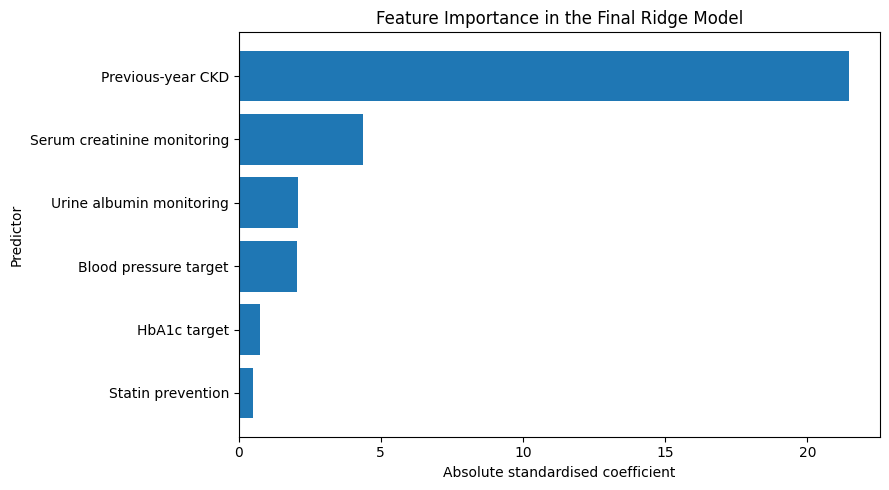

In [73]:
feature_labels = {
    "previous_year_ckd": "Previous-year CKD",
    "serum_creatinine": "Serum creatinine monitoring",
    "urine_albumin": "Urine albumin monitoring",
    "blood_pressure_le_140_80": "Blood pressure target",
    "hba1c_le_58_mmol_mol_7_5pct": "HbA1c target",
    "combined_prevention_on_statins": "Statin prevention"
}

plot_data = coefficient_table.copy()

plot_data["Label"] = (
    plot_data["Feature"]
    .map(feature_labels)
)

# Sort for horizontal plot
plot_data = plot_data.sort_values(
    "Absolute Importance",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["Label"],
    plot_data["Absolute Importance"]
)

plt.xlabel("Absolute standardised coefficient")
plt.ylabel("Predictor")
plt.title("Feature Importance in the Final Ridge Model")

plt.tight_layout()
plt.show()

result vs prediction

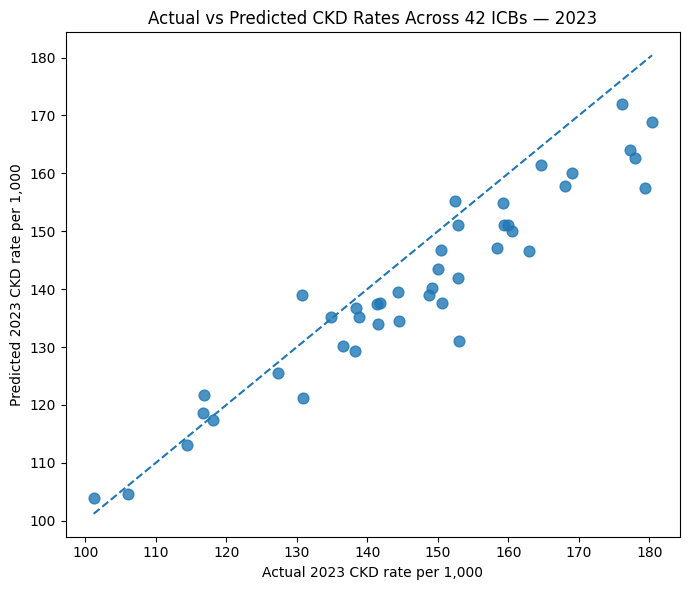

In [74]:


plt.figure(figsize=(7, 6))

plt.scatter(
    final_test["ckd_rate_per_1000"],
    final_test["predicted_ckd"],
    s=60,
    alpha=0.8
)

# Perfect-prediction reference line
min_value = min(
    final_test["ckd_rate_per_1000"].min(),
    final_test["predicted_ckd"].min()
)

max_value = max(
    final_test["ckd_rate_per_1000"].max(),
    final_test["predicted_ckd"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual 2023 CKD rate per 1,000")
plt.ylabel("Predicted 2023 CKD rate per 1,000")

plt.title(
    "Actual vs Predicted CKD Rates Across 42 ICBs — 2023"
)

plt.tight_layout()
plt.show()

prediction error

In [75]:


largest_errors = (
    final_test[
        [
            "icb_code",
            "icb_name",
            "ckd_rate_per_1000",
            "predicted_ckd",
            "absolute_error"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
    .copy()
)

largest_errors = largest_errors.rename(
    columns={
        "ckd_rate_per_1000": "Actual CKD",
        "predicted_ckd": "Predicted CKD",
        "absolute_error": "Absolute Error"
    }
)

print("=" * 65)
print("TOP 10 LARGEST PREDICTION ERRORS — 2023")
print("=" * 65)

display(
    largest_errors.round(2)
)

TOP 10 LARGEST PREDICTION ERRORS — 2023


,icb_code,icb_name,Actual CKD,Predicted CKD,Absolute Error
159,QK1,"NHS LEICESTER, LEICESTERSHIRE AND RUTLAND INTE...",153.0,131.07,21.93
142,QJM,NHS LINCOLNSHIRE INTEGRATED CARE BOARD,179.4,157.49,21.91
126,QSL,NHS SOMERSET INTEGRATED CARE BOARD,162.9,146.61,16.29
128,QJG,NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CA...,178.0,162.71,15.29
150,QVV,NHS DORSET INTEGRATED CARE BOARD,177.3,164.01,13.29
166,QKS,NHS KENT AND MEDWAY INTEGRATED CARE BOARD,150.6,137.56,13.04
165,QOC,"NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...",180.4,168.83,11.57
137,QMM,NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD,158.4,147.14,11.26
134,QRL,NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...,152.9,141.86,11.04
152,QOX,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...",160.6,150.02,10.58


graph comparison

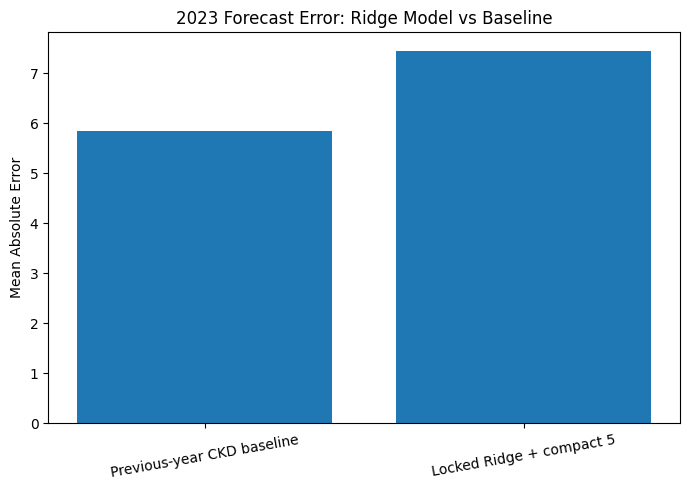

2023 MAE comparison:


,Model,MAE
0,Previous-year CKD baseline,5.838
1,Locked Ridge + compact 5,7.446


In [76]:


comparison_plot = pd.DataFrame({
    "Model": [
        "Previous-year CKD baseline",
        "Locked Ridge + compact 5"
    ],
    "MAE": [
        baseline_2023_mae,
        final_mae
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    comparison_plot["Model"],
    comparison_plot["MAE"]
)

plt.ylabel("Mean Absolute Error")
plt.title("2023 Forecast Error: Ridge Model vs Baseline")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

print("2023 MAE comparison:")
display(comparison_plot.round(3))

final result


In [77]:
# ============================================================
# STEP 44: SAVE FINAL DISSERTATION RESULTS
# ============================================================

# Save the complete forecasting dataset
forecast_panel.to_csv(
    RESULTS_DIR / "forecasting_panel.csv",
    index=False
)

# Save model-selection comparison
model_selection_summary.to_csv(
    RESULTS_DIR / "model_selection_summary.csv",
    index=False
)

# Save final 2023 predictions
final_test.to_csv(
    RESULTS_DIR / "final_2023_predictions.csv",
    index=False
)

# Save Ridge coefficient / feature-importance table
coefficient_table.to_csv(
    RESULTS_DIR / "final_ridge_coefficients.csv",
    index=False
)

# Save final model vs baseline comparison
final_comparison.to_csv(
    RESULTS_DIR / "final_2023_model_vs_baseline.csv",
    index=False
)

# Save largest prediction errors
largest_errors.to_csv(
    RESULTS_DIR / "largest_2023_prediction_errors.csv",
    index=False
)

print("=" * 65)
print("FINAL RESULTS SAVED")
print("=" * 65)

for file in sorted(RESULTS_DIR.iterdir()):
    print(" -", file.name)


FINAL RESULTS SAVED
 - final_2023_model_vs_baseline.csv
 - final_2023_predictions.csv
 - final_ridge_coefficients.csv
 - forecasting_panel.csv
 - largest_2023_prediction_errors.csv
 - model_selection_summary.csv


In [79]:


print("=" * 70)
print("FINAL DISSERTATION SUMMARY")
print("=" * 70)

print("\nDATASET")
print("42 NHS Integrated Care Boards")
print("4 predictor years: 2018/19 to 2021/22")
print("4 CKD target years: 2020 to 2023")
print("168 total ICB-year forecasting observations")
print("19 harmonised NDA predictors")
print("0 missing predictor values")

print("\nFINAL MODEL")
print("Ridge Regression")
print("Alpha: 1.0")
print("Previous-year CKD + 5 compact NDA predictors")

print("\nFINAL 2023 TEST PERFORMANCE")
print(f"MAE  : {final_mae:.3f}")
print(f"RMSE : {final_rmse:.3f}")
print(f"R²   : {final_r2:.3f}")

print("\n2023 PREVIOUS-YEAR BASELINE")
print(f"MAE  : {baseline_2023_mae:.3f}")
print(f"RMSE : {baseline_2023_rmse:.3f}")
print(f"R²   : {baseline_2023_r2:.3f}")




FINAL DISSERTATION SUMMARY

DATASET
42 NHS Integrated Care Boards
4 predictor years: 2018/19 to 2021/22
4 CKD target years: 2020 to 2023
168 total ICB-year forecasting observations
19 harmonised NDA predictors
0 missing predictor values

FINAL MODEL
Ridge Regression
Alpha: 1.0
Previous-year CKD + 5 compact NDA predictors

FINAL 2023 TEST PERFORMANCE
MAE  : 7.446
RMSE : 9.117
R²   : 0.786

2023 PREVIOUS-YEAR BASELINE
MAE  : 5.838
RMSE : 7.385
R²   : 0.860


This study developed and evaluated a time-aware machine-learning pipeline for forecasting chronic kidney disease (CKD) outcomes across 42 NHS Integrated Care Boards using publicly available aggregated diabetes data.

Historical National Diabetes Audit data were harmonised across changing NHS geographies and combined with CKD outcome data to construct a longitudinal forecasting panel containing 168 ICB-year observations.

Several modelling approaches were evaluated using chronological rolling-origin validation. Models based on all 19 NDA indicators showed substantial instability, highlighting the risk of overfitting when using a relatively small number of geographical observations with correlated predictors.

A compact Ridge regression model was therefore selected using previous-year CKD together with five clinically meaningful NDA indicators representing renal monitoring, glycaemic control, blood-pressure control and cardiovascular prevention.

On the unseen 2023 test year, the final Ridge model achieved:

- **MAE: 7.446**
- **RMSE: 9.117**
- **R²: 0.786**

However, the previous-year CKD baseline achieved stronger performance:

- **MAE: 5.838**
- **RMSE: 7.385**
- **R²: 0.860**

This indicates that CKD outcomes at ICB level demonstrate substantial year-to-year persistence. The additional NDA indicators contributed interpretable information but did not improve one-year-ahead forecasting accuracy beyond the simple persistence baseline.

Model interpretation further showed that previous-year CKD was by far the dominant predictor, while serum creatinine monitoring, urine albumin monitoring, blood-pressure achievement, HbA1c control and statin prevention provided smaller additional contributions.

Overall, the study demonstrates both the potential and limitations of explainable machine learning using aggregated public NHS data for regional diabetic-complication forecasting.